In [21]:
import numpy as np
import pandas as pd
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.neighbors import LocalOutlierFactor
from sklearn.model_selection import train_test_split
from pathlib import Path
import shap
import matplotlib.pyplot as plt

In [22]:
# Load datasets
normal = pd.read_csv("no-jammer.csv").dropna()
jammer = pd.read_csv("jammer.csv").dropna()


In [23]:
# Select features
anomalyInputs = [
   "SF", "CF", "TX", "BW", "CR", "SNR", "RSSI", "PktSeqNum", 
   "payloadSize", "numReceivedPerNode[nodeNumber-1]", "PDRPerNode", 
   "numReceivedPerNodePerWindow[nodeNumber]", "currentSeqNum", 
   "lastSeqNumAtWindowStart[nodeNumber]", "pdrPerNodePerWindow[nodeNumber]", 
   "interArrivalTime_s", "interArrivalTimeMin" 
]

anomalyInputs1 = [
   "SF", "CF", "SNR", "RSSI", "PktSeqNum", "numReceivedPerNode[nodeNumber-1]", "PDRPerNode", 
   "numReceivedPerNodePerWindow[nodeNumber]", "currentSeqNum", 
   "lastSeqNumAtWindowStart[nodeNumber]", "pdrPerNodePerWindow[nodeNumber]", 
   "interArrivalTime_s", "interArrivalTimeMin" 
]

anomalyInputs2 = [
   "SF", "CF", "SNR", "RSSI", "PktSeqNum", "currentSeqNum", "lastSeqNumAtWindowStart[nodeNumber]", "interArrivalTime_s", "interArrivalTimeMin" 
]

anomalyInputs3 = [
   "SF", "CF", "SNR", "RSSI", "interArrivalTime_s", "interArrivalTimeMin" 
]

anomalyInputs4 = [
   "SF", "CF", "SNR", "RSSI", "interArrivalTime_s",  
]

In [24]:
scaler = StandardScaler()

# Cleaning up column names
normal.columns = normal.columns.str.strip()
jammer.columns = jammer.columns.str.strip()

normal2 = scaler.fit_transform(normal[anomalyInputs3]) 
jammer2 = scaler.transform(jammer[anomalyInputs3])

print(f"Normal set length: {len(normal)}")
print(f"Jammer set length: {len(jammer)}")

Normal set length: 99381
Jammer set length: 98752


In [25]:
# Use 80% to train the "baseline" of your network
normalTrain, normalTest = train_test_split(normal2, test_size=0.2, random_state=42)

# Training models ONLY on clean normal data
contamination = 0.01 
#contamination = 'auto'

model = IsolationForest(contamination=contamination, random_state=42)
model.fit(normalTrain)

model2 = LocalOutlierFactor(contamination=contamination, novelty=True)
model2.fit(normalTrain)

,n_neighbors,20
,algorithm,'auto'
,leaf_size,30
,metric,'minkowski'
,p,2
,metric_params,None
,contamination,0.01
,novelty,True
,n_jobs,None


In [26]:
# Test on 20% normal set
predNormalTestIF = (model.predict(normalTest) == -1).astype(int)
yTrueNormalIF = np.zeros(len(normalTest))
accNormalIF = accuracy_score(yTrueNormalIF, predNormalTestIF)
print(accNormalIF)

# Test on jammer set
jammer['anomaly'] = model.predict(jammer2)
jammer['isAnomaly'] = (jammer['NodeID'] == 121).astype(int)
predictionJammerIF = (jammer['anomaly'] == -1).astype(int) 
yTrueJammerIF = jammer['isAnomaly']
accJammerIF = accuracy_score(yTrueJammerIF, predictionJammerIF)
print(accJammerIF)

0.9897368818232127
0.7927940699935191


Classification Report - IF
              precision    recall  f1-score   support

           0       0.79      0.95      0.86     66229
           1       0.81      0.48      0.61     32523

    accuracy                           0.79     98752
   macro avg       0.80      0.71      0.73     98752
weighted avg       0.80      0.79      0.78     98752



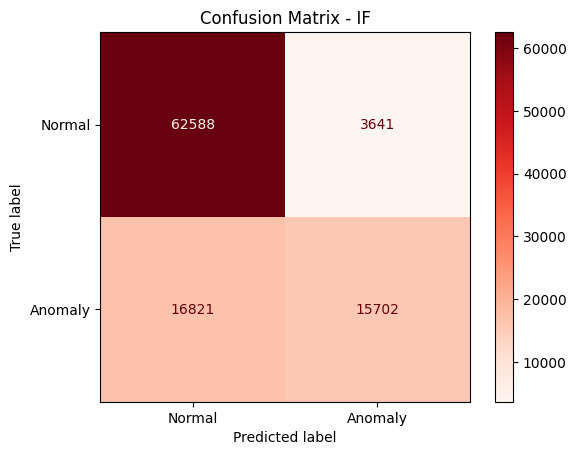

In [27]:
# Final evaluation metrics
print("Classification Report - IF")
print(classification_report(yTrueJammerIF, predictionJammerIF))

cm = confusion_matrix(yTrueJammerIF, predictionJammerIF)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Anomaly'])
disp.plot(cmap=plt.cm.Reds)
plt.title('Confusion Matrix - IF')
plt.show()

In [28]:
# Test on 20% normal set
predNormalTestLOF = (model2.predict(normalTest) == -1).astype(int)
yTrueNormalLOF = np.zeros(len(normalTest))
accNormalLOF = accuracy_score(yTrueNormalLOF, predNormalTestLOF)
print(accNormalLOF)

# Test on jammer set
jammer['anomaly'] = model2.predict(jammer2)
jammer['isAnomaly'] = (jammer['NodeID'] == 121).astype(int)
predictionJammerLOF = (jammer['anomaly'] == -1).astype(int) 
yTrueJammerLOF = jammer['isAnomaly']
accJammerLOF = accuracy_score(yTrueJammerLOF, predictionJammerLOF)
print(accJammerLOF)

0.9900890476430044
0.9324570641607258


Classification Report - LOF
              precision    recall  f1-score   support

           0       0.96      0.94      0.95     66229
           1       0.89      0.91      0.90     32523

    accuracy                           0.93     98752
   macro avg       0.92      0.93      0.92     98752
weighted avg       0.93      0.93      0.93     98752



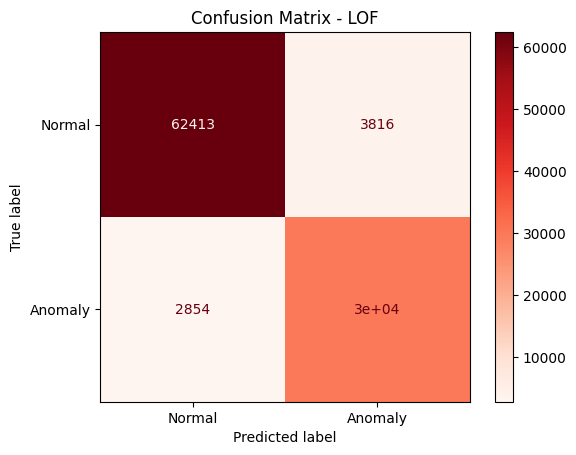

In [29]:
# Final evaluation metrics
print("Classification Report - LOF")
print(classification_report(yTrueJammerLOF, predictionJammerLOF))

cm = confusion_matrix(yTrueJammerLOF, predictionJammerLOF)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Anomaly'])
disp.plot(cmap=plt.cm.Reds)
plt.title('Confusion Matrix - LOF')
plt.show()

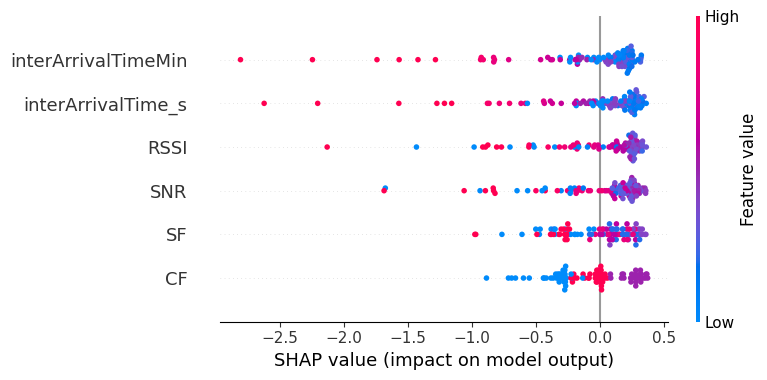

In [ ]:
# Explain the model using SHAP
explainer = shap.TreeExplainer(model)
XSample = pd.DataFrame(normalTrain[:100], columns=anomalyInputs4)
shapValues = explainer.shap_values(XSample)
shap.summary_plot(shapValues, XSample)